Simulating 2D Adsorption
System Size: Lx = 30.0 Å, Ly = 30.0 Å
Bulk Vapor Density : 3.748828e-05 Å⁻³
Solving 2D DFT for adsorption profile...
Density Map Range  : [7.514719e-13, 3.816423e-05] Å⁻³


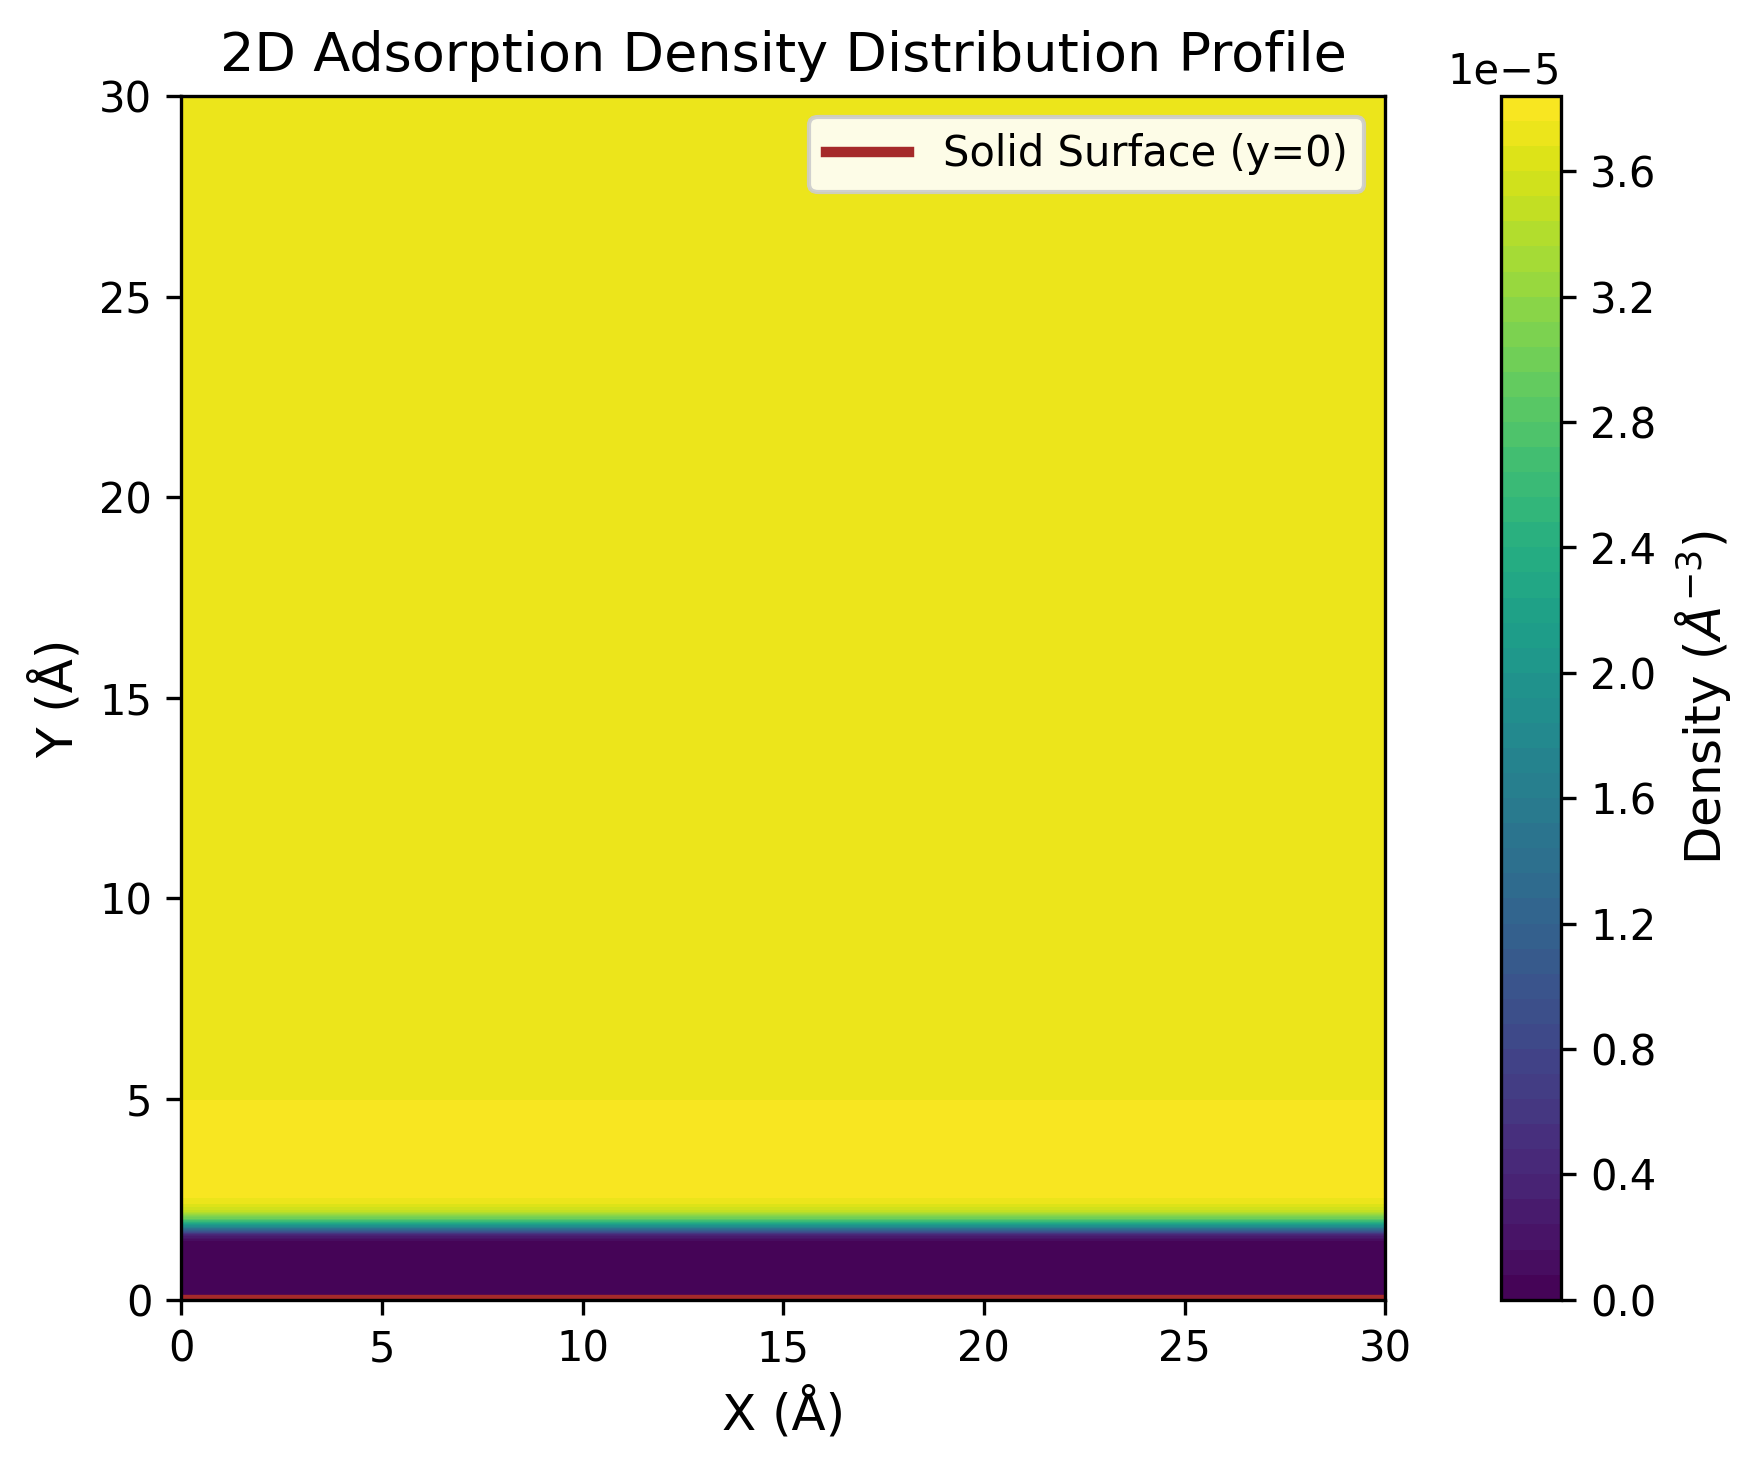

Calculation finished successfully.
Results and 2D density plots are saved in: 2D_adsorption


In [2]:
import os
import feos
import si_units as si
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants
from si_units import ANGSTROM, KELVIN, BAR, METER, MOL, KILO

###############################################
# 1. Core Control Parameters
###############################################
factor_SF = 0.25 # Scale factor for fluid-wall interaction
T_val = 119.86 * 0.7  # Temperature numerical value in K

# 2D system grid and dimensions (Unit: Å)
Lx_val = 30.0  # Dimension in X direction
Ly_val = 30.0   # Dimension in Y direction (perpendicular to wall)
Nx, Ny = int(Lx_val * 5), int(Ly_val * 5)

###############################################
# 2. Create Output Directory
###############################################
suffix = "2D_adsorption"
folder_name = f"{suffix}"
os.makedirs(folder_name, exist_ok=True)

print("=" * 60)
print(f"Simulating 2D Adsorption")
print(f"System Size: Lx = {Lx_val} Å, Ly = {Ly_val} Å")
print("=" * 60)

###############################################
# 4. Set Up Fluid Thermodynamic Model (feos)
###############################################
parameters = feos.Parameters.from_json(["argon"], "../parameters/pcsaft/gross2001.json")

dippr_parameters = feos.Parameters.from_json(substances=["argon"], pure_path="../parameters/ideal_gas/poling2000.json")

functional = (
    feos.HelmholtzEnergyFunctional.pcsaft(parameters).dippr(dippr_parameters)
)

solver = feos.DFTSolver().picard_iteration(tol=1e-10, damping_coefficient=0.1).anderson_mixing()

###############################################
# 5. Bulk States & Unit Conversion
###############################################
vle = feos.PhaseEquilibrium.pure(functional, T_val * si.KELVIN)
rho_G_val = vle.vapor.density
ve = feos.State(
    functional,
    T_val * si.KELVIN,
    None,
    rho_G_val,
)

# Extract numerical value in mol/m³ and convert to 1/Å³
rho_v_m3 = float(ve.density / (si.MOL / si.METER**3))
rho_v_val = rho_v_m3 * constants.Avogadro * 1e-30

print(f"Bulk Vapor Density : {rho_v_val:.6e} Å⁻³")

###############################################
# 6. Set Up 2D Pore & External Potential (LJ 9-3 Wall)
###############################################
x_coords = np.linspace(0, Lx_val, Nx)
y_coords = np.linspace(0, Ly_val, Ny)

# LJ 9-3 wall potential parameters
sig_ss = 3.405
eps_k_ss = (factor_SF / 2 / np.pi) ** 2 * 119.86
rho_s = 0.1137

# Calculate external potential (in K) and convert to dimensionless [kT] by dividing by T_val (in K)
def lj_9_3_in_kt(z, T_K):
    z = np.maximum(z, 0.1)
    term9 = (1.0 / 45.0) * (sig_ss / z) ** 9
    term3 = (1.0 / 6.0) * (sig_ss / z) ** 3
    v_ext_K = 4.0 * np.pi * rho_s * eps_k_ss * (sig_ss**3) * (term9 - term3)
    return v_ext_K / T_K  # Convert to kT units

# Construct 2D external potential array (contiguous float64 array of shape [1, Nx, Ny])
v_ext_2d = np.zeros((1, Nx, Ny), dtype=np.float64)
for j, y in enumerate(y_coords):
    v_ext_2d[0, :, j] = lj_9_3_in_kt(y, T_val)

# Cap the external potential at 49.99 kT to prevent numerical underflow and solver instability
v_ext_2d = np.clip(v_ext_2d, a_min=None, a_max=49.99)

pore_2d = feos.Pore2D(
    system_size=[Lx_val * si.ANGSTROM, Ly_val * si.ANGSTROM],
    n_grid=[Nx, Ny],
    angle=90 * si.DEGREES,
)

###############################################
# 7. Construct Initial Density Field (Uniform 2D Vapor Field)
###############################################
# Initialize entire field to bulk vapor density as contiguous float64 array
init_density_raw = np.full((1, Nx, Ny), rho_v_val, dtype=np.float64)

# Pure numerical conversion: 1/Å³ -> mol/m³ as contiguous array
init_density_mol_m3 = np.ascontiguousarray(
    init_density_raw * 1e30 / constants.Avogadro, dtype=np.float64
)

# Bind density units
init_density_si = init_density_mol_m3*(si.MOL / si.METER**3)

###############################################
# 8. Perform 2D DFT Calculation
###############################################
print("Solving 2D DFT for adsorption profile...")
profile2d = pore_2d.initialize(
    bulk=ve, density=init_density_si, external_potential=v_ext_2d
).solve(solver)

# Convert physical unit of density to 1/Å³
density_mol_m3 = np.asarray(profile2d.density[0] / (si.MOL / si.METER**3), dtype=np.float64)
density_map = (density_mol_m3 * constants.Avogadro * 1e-30).T

print(f"Density Map Range  : [{np.min(density_map):.6e}, {np.max(density_map):.6e}] Å⁻³")

###############################################
# 9. Save 2D Density Profile Data
###############################################
np.savetxt(
    os.path.join(folder_name, "density_profile_2d.txt"),
    density_map,
    header=f"2D Adsorption Profile\nLx={Lx_val}A, Ly={Ly_val}A, Nx={Nx}, Ny={Ny}",
    fmt="%.8e",
)

###############################################
# 10. Plot 2D Density Distribution Map
###############################################
plt.figure(figsize=(8, 5), dpi=300)

# Plot 2D density contour map
contour = plt.contourf(
    x_coords, y_coords, density_map, levels=60, cmap="viridis"
)
cbar = plt.colorbar(contour)
cbar.set_label(r"Density ($\AA^{-3}$)", fontsize=12)

# Highlight solid wall boundary (y=0)
plt.axhline(0, color="brown", linewidth=2.5, label="Solid Surface (y=0)")

plt.xlim(0, Lx_val)
plt.ylim(0, Ly_val)
plt.xlabel("X (Å)", fontsize=12)
plt.ylabel("Y (Å)", fontsize=12)
plt.title("2D Adsorption Density Distribution Profile", fontsize=13)
plt.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9)
plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig(os.path.join(folder_name, "2d_adsorption_density.png"), dpi=600)
plt.show()

print("Calculation finished successfully.")
print(f"Results and 2D density plots are saved in: {folder_name}")
print("=" * 60)